<a href="https://colab.research.google.com/github/renatoruiz2607/fiapCursoTecIA/blob/dev/fase5/cap1/fiapAgroAnalytics/RenatoRuizCai_RM572235_fase5_cap1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Fase 5 - Cap 1
## FarmTech Solutions

*Nesta atividade será desenvolvido um projeto de análise de dados e Machine Learning para a FarmTech Solutions, empresa de prestação de serviços de IA para o agronegócio.*

*O cenário proposto envolve uma fazenda de médio porte, com aproximadamente 200 hectares (o equivalente a cerca de 210 campos de futebol oficiais), responsável pelo cultivo de diferentes produtos agrícolas. A equipe de dados precisa analisar uma base contendo condições climáticas do solo e informações sobre o tipo de cultura plantada, com o objetivo de apoiar decisões de manejo e planejamento de safra.*

*O objetivo desta entrega é duplo. Primeiro, prever o rendimento de safra (Yield) a partir das condições climáticas e da cultura plantada, utilizando técnicas de Regressão Supervisionada. Em seguida, explorar a tendência de produtividade por meio de técnicas de Machine Learning Não Supervisionado, com o objetivo de identificar padrões climáticos e possíveis cenários discrepantes (outliers).*

*O trabalho seguirá a metodologia CRISP-DM, contemplando as etapas de entendimento dos dados, preparação dos dados, modelagem, avaliação e interpretação dos resultados.*

*A base de dados utilizada é o arquivo `crop_yield.csv`, contendo variáveis de precipitação, umidade específica, umidade relativa e temperatura a 2 metros do solo, além da cultura plantada e do rendimento de safra observado (em toneladas por hectare).*

*Para fins acadêmicos e para análise imediata, o projeto foi executado por completo antes do salvamento e todas as informações estão disponíveis.*

## Módulos + Importação do Dataset + Nomeação das Colunas

In [1]:
# modulos
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# Configuração de exibição do pandas
# ------------------------------------------------------------
# Por padrão, o pandas limita a largura das tabelas impressas com print()
# a 80 caracteres, ocultando colunas do meio com "...". As opções abaixo
# removem esse limite para que todas as colunas apareçam nos prints.
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Importação do Dataset
dados = pd.read_csv('crop_yield.csv')

# Nomeação das Colunas
dados.columns = [
    'cultura',
    'precipitacao_mm_dia',
    'umidade_especifica_2m',
    'umidade_relativa_2m',
    'temperatura_2m',
    'rendimento'
]

dados.head()

,cultura,precipitacao_mm_dia,umidade_especifica_2m,umidade_relativa_2m,temperatura_2m,rendimento
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


*Após a importação do dataset, foi realizada a nomeação das colunas, uma vez que o arquivo original possui cabeçalhos extensos e com unidades de medida embutidas no nome. Durante esse processo, foram atribuídos nomes mais curtos e descritivos para as variáveis de precipitação, umidade específica, umidade relativa, temperatura e rendimento de safra, além da variável `cultura`, responsável por indicar o tipo de produto agrícola ao qual cada registro se refere.*

*A base contempla quatro culturas distintas: `Cocoa, beans`, `Oil palm fruit`, `Rice, paddy` e `Rubber, natural`, cada uma associada às condições climáticas registradas e ao respectivo rendimento de safra observado, em toneladas por hectare.*

## Preparação dos dados para Machine Learning

In [2]:
# ------------------------------------------------------------
# Separação entre variáveis explicativas e variável alvo
# ------------------------------------------------------------

X = dados.drop('rendimento', axis=1)

y = dados['rendimento']

print(X.shape)
print(y.shape)

# ------------------------------------------------------------
# Avaliação da necessidade de padronização e encoding
# ------------------------------------------------------------

variaveis_climaticas = X.drop(columns=['cultura'])

df_escalas = pd.DataFrame({
    'Mínimo': variaveis_climaticas.min(),
    'Máximo': variaveis_climaticas.max(),
    'Amplitude': (variaveis_climaticas.max() - variaveis_climaticas.min()).round(2)
})

print(df_escalas)

print('\nValores únicos da variável categórica "cultura":')
print(X['cultura'].unique())

(156, 5)
(156,)
                        Mínimo   Máximo  Amplitude
precipitacao_mm_dia    1934.62  3085.79    1151.17
umidade_especifica_2m    17.54    18.70       1.16
umidade_relativa_2m      82.11    86.10       3.99
temperatura_2m           25.56    26.81       1.25

Valores únicos da variável categórica "cultura":
['Cocoa, beans' 'Oil palm fruit' 'Rice, paddy' 'Rubber, natural']


*Nesta etapa foi realizada a preparação dos dados para utilização nos modelos de Machine Learning.*

*Inicialmente, a base foi separada entre variáveis explicativas (X) e variável alvo (y). O conjunto de variáveis explicativas ficou composto por 156 registros e 5 atributos (`cultura` e quatro variáveis climáticas), enquanto a variável alvo manteve os 156 registros correspondentes ao rendimento de safra observado.*

*Em seguida, foi avaliada a necessidade de padronização dos dados por meio da análise das amplitudes das variáveis climáticas numéricas. Os resultados demonstraram diferenças consideráveis de escala entre os atributos: enquanto a `umidade_especifica_2m` apresentou amplitude de apenas 1,16 e a `temperatura_2m` de 1,25, a `precipitacao_mm_dia` apresentou amplitude de 1.151,17.*

*Essas diferenças indicam que algumas variáveis climáticas possuem magnitudes significativamente maiores que outras, o que pode influenciar negativamente algoritmos sensíveis à escala dos dados, como K-Nearest Neighbors (KNN), Support Vector Regression (SVR) e a própria clusterização com K-Means.*

*Também foi identificada a variável `cultura` como categórica nominal, com quatro categorias distintas. Como os algoritmos de Machine Learning trabalham exclusivamente com valores numéricos, essa variável precisará ser codificada por meio de One-Hot Encoding antes de ser utilizada nos modelos preditivos.*

*Para seguir as boas práticas de Machine Learning e evitar vazamento de dados, a padronização das variáveis climáticas e a codificação da variável `cultura` serão aplicadas posteriormente por meio de Pipelines (com `ColumnTransformer`) durante as etapas de clusterização e de modelagem.*

## Análise Exploratória

### Tamanho da base, tipos de dados e valores nulos

In [3]:
# ------------------------------------------------------------
# Tamanho da base de dados
# ------------------------------------------------------------

linhas, colunas = dados.shape
print('-- Tamanho da base de dados --')
print(f'A base possui {linhas} exemplos (linhas) e {colunas} variáveis (colunas).\n')

# ------------------------------------------------------------
# Tipos de dados e valores nulos
# ------------------------------------------------------------

df_info = pd.DataFrame({
    'Tipo de dado': dados.dtypes,
    'Valores nulos': dados.isnull().sum()
})

print('\n-- Tipos de dados e valores nulos --')
print(df_info)
print("")

# ------------------------------------------------------------
# Tipos de variáveis
# ------------------------------------------------------------

variaveis_numericas = dados.select_dtypes(include=['int64', 'float64']).columns
variaveis_categoricas = dados.select_dtypes(include=['object']).columns

print('-- Tipos de variáveis --')
print('Variáveis numéricas:')
print(variaveis_numericas)

print('\nVariáveis categóricas:')
print(variaveis_categoricas)
print("")

# ------------------------------------------------------------
# Classificação das variáveis numéricas
# ------------------------------------------------------------

variaveis_discretas = dados.select_dtypes(include=['int64']).columns
variaveis_continuas = dados.select_dtypes(include=['float64']).columns

print('Variáveis discretas:')
print(variaveis_discretas)

print('\nVariáveis contínuas:')
print(variaveis_continuas)
print("")

# ------------------------------------------------------------
# Classificação das variáveis categóricas
# ------------------------------------------------------------

print('Variáveis nominais:')
print(variaveis_categoricas)

print('\nVariáveis ordinais:')
print('Não há variáveis ordinais na base.')

-- Tamanho da base de dados --
A base possui 156 exemplos (linhas) e 6 variáveis (colunas).


-- Tipos de dados e valores nulos --
                      Tipo de dado  Valores nulos
cultura                     object              0
precipitacao_mm_dia        float64              0
umidade_especifica_2m      float64              0
umidade_relativa_2m        float64              0
temperatura_2m             float64              0
rendimento                   int64              0

-- Tipos de variáveis --
Variáveis numéricas:
Index(['precipitacao_mm_dia', 'umidade_especifica_2m', 'umidade_relativa_2m', 'temperatura_2m', 'rendimento'], dtype='object')

Variáveis categóricas:
Index(['cultura'], dtype='object')

Variáveis discretas:
Index(['rendimento'], dtype='object')

Variáveis contínuas:
Index(['precipitacao_mm_dia', 'umidade_especifica_2m', 'umidade_relativa_2m', 'temperatura_2m'], dtype='object')

Variáveis nominais:
Index(['cultura'], dtype='object')

Variáveis ordinais:
Não há variáve

*A análise exploratória inicial permitiu compreender a estrutura geral da base de dados utilizada no projeto. O dataset possui 156 exemplos (linhas) e 6 variáveis (colunas), representando condições climáticas, a cultura plantada e o rendimento de safra observado.*

*Em relação aos tipos de dados, as variáveis `precipitacao_mm_dia`, `umidade_especifica_2m`, `umidade_relativa_2m` e `temperatura_2m` foram identificadas como numéricas decimais (float64). A variável `rendimento` foi identificada como numérica discreta (int64), enquanto a variável `cultura` foi identificada como categórica (object).*

*Também foi verificado que nenhuma variável apresenta valores nulos, indicando boa qualidade e consistência dos dados utilizados no projeto.*

*Do ponto de vista analítico, as quatro variáveis climáticas foram classificadas como numéricas contínuas, por representarem medições que podem assumir valores decimais, enquanto o rendimento foi classificado como variável numérica discreta, medida em toneladas por hectare. Já a variável `cultura` foi classificada como categórica nominal, pois representa diferentes produtos agrícolas sem qualquer relação de ordem ou hierarquia entre eles.*

*Não foram identificadas variáveis ordinais na base de dados. Essa etapa foi fundamental para validar a integridade da base de dados e garantir que as variáveis estivessem adequadamente preparadas para as análises estatísticas, visuais, de clusterização e para o desenvolvimento dos modelos preditivos de Machine Learning.*

### Identificação de outliers

In [4]:
# ------------------------------------------------------------
# Identificação de outliers (base completa)
# ------------------------------------------------------------

colunas_numericas = dados.drop(
    columns=['cultura']
)

Q1 = colunas_numericas.quantile(0.25)
Q3 = colunas_numericas.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = ((colunas_numericas < limite_inferior) |
            (colunas_numericas > limite_superior))

quantidade_outliers = outliers.sum()

percentual_outliers = (
    (quantidade_outliers / len(dados)) * 100
).round(2)

df_outliers = pd.DataFrame({
    'Quantidade ': quantidade_outliers,
    'Percentual (%)': percentual_outliers
})

print('\n-- Identificação de outliers (base completa) --')
print(df_outliers)

# ------------------------------------------------------------
# Identificação de outliers de rendimento POR CULTURA
# ------------------------------------------------------------

def identifica_outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((serie < li) | (serie > ls)).sum()

outliers_rendimento_por_cultura = dados.groupby('cultura')['rendimento'].apply(
    identifica_outliers_iqr
)

print('\n-- Outliers de rendimento identificados dentro de cada cultura --')
print(outliers_rendimento_por_cultura)


-- Identificação de outliers (base completa) --
                       Quantidade   Percentual (%)
precipitacao_mm_dia              0            0.00
umidade_especifica_2m            0            0.00
umidade_relativa_2m              0            0.00
temperatura_2m                  12            7.69
rendimento                      35           22.44

-- Outliers de rendimento identificados dentro de cada cultura --
cultura
Cocoa, beans       0
Oil palm fruit     0
Rice, paddy        0
Rubber, natural    0
Name: rendimento, dtype: int64


*Foi realizada uma análise de outliers utilizando o método do Intervalo Interquartil (IQR), com o objetivo de identificar valores discrepantes nas variáveis climáticas e no rendimento de safra presentes na base de dados.*

*Ao aplicar o método na base completa, a variável `rendimento` apresentou 35 registros classificados como outliers (22,44% da base) e a `temperatura_2m` apresentou 12 registros (7,69%). As demais variáveis climáticas não apresentaram valores discrepantes segundo esse critério.*

*Entretanto, essa quantidade elevada de outliers em `rendimento` é um artefato da mistura de escalas entre as quatro culturas presentes na base, e não indica, por si só, um problema de qualidade dos dados. A cultura `Oil palm fruit` apresenta rendimentos médios muito superiores (na casa de 175 mil toneladas por hectare) aos das demais culturas (entre aproximadamente 7,8 mil e 32 mil), fazendo com que seus registros sejam identificados como outliers quando o IQR é calculado sobre a base como um todo.*

*Ao repetir a análise separadamente para cada cultura, nenhum outlier de rendimento foi identificado, confirmando que os valores aparentemente discrepantes são, na verdade, o comportamento esperado de culturas com potenciais produtivos muito diferentes entre si, e não anomalias pontuais nos dados.*

*Essa constatação reforça a importância de considerar a variável `cultura` como referência para qualquer análise de outliers ou de tendência de produtividade, o que será retomado na etapa de clusterização a seguir.*

### Quantidade e percentual das culturas

In [5]:
# ------------------------------------------------------------
# Quantidade e percentual das culturas
# ------------------------------------------------------------

quantidade_culturas = dados['cultura'].value_counts()

percentual_culturas = (
    dados['cultura'].value_counts(normalize=True) * 100
).round(2)

distribuicao_culturas = pd.DataFrame({
    'Quantidade': quantidade_culturas,
    'Percentual (%)': percentual_culturas
})

print('\n-- Quantidade e percentual das culturas --')
print(distribuicao_culturas)


-- Quantidade e percentual das culturas --
                 Quantidade  Percentual (%)
cultura                                    
Cocoa, beans             39            25.0
Oil palm fruit           39            25.0
Rice, paddy              39            25.0
Rubber, natural          39            25.0


*Foi realizada a análise da distribuição das culturas presentes na variável `cultura`, responsável por representar os diferentes produtos agrícolas cultivados pela fazenda.*

*Os resultados demonstraram que o dataset possui distribuição perfeitamente balanceada entre as quatro culturas analisadas: `Cocoa, beans`, `Oil palm fruit`, `Rice, paddy` e `Rubber, natural`. Cada cultura possui 39 registros, representando exatamente 25% do total da base.*

*Esse equilíbrio entre as categorias é uma característica positiva para o desenvolvimento dos modelos preditivos, pois reduz o risco de os algoritmos apresentarem viés em favor de uma determinada cultura durante o treinamento, além de favorecer uma avaliação mais confiável das métricas de desempenho.*

### Correlação entre variáveis

In [6]:
# ------------------------------------------------------------
# Correlação entre variáveis
# ------------------------------------------------------------

correlacao = dados.drop(
    columns=['cultura']
).corr()

df_correlacao = correlacao.round(3)

print('\n-- Correlação entre variáveis --')
print(df_correlacao)


-- Correlação entre variáveis --
                       precipitacao_mm_dia  umidade_especifica_2m  umidade_relativa_2m  temperatura_2m  rendimento
precipitacao_mm_dia                  1.000                  0.488                0.749          -0.084       0.019
umidade_especifica_2m                0.488                  1.000                0.437           0.699       0.013
umidade_relativa_2m                  0.749                  0.437                1.000          -0.337       0.000
temperatura_2m                      -0.084                  0.699               -0.337           1.000       0.013
rendimento                           0.019                  0.013                0.000           0.013       1.000


*Foi realizada uma análise de correlação entre as variáveis numéricas da base de dados com o objetivo de identificar possíveis relações lineares entre as condições climáticas e o rendimento de safra.*

*Os resultados demonstraram correlações moderadas a fortes entre as próprias variáveis climáticas. Destacam-se a correlação entre `precipitacao_mm_dia` e `umidade_relativa_2m` (0,749), entre `umidade_especifica_2m` e `temperatura_2m` (0,699), além da correlação negativa entre `umidade_relativa_2m` e `temperatura_2m` (-0,337). Esses resultados indicam que regiões mais chuvosas tendem a apresentar maior umidade relativa, e que dias mais quentes tendem a ser acompanhados de menor umidade relativa do ar.*

*Em contrapartida, a correlação entre as variáveis climáticas e o `rendimento` foi praticamente nula em todos os casos, com valores entre 0,00 e 0,02. Esse resultado, à primeira vista inesperado, sugere que a variação do rendimento observada na base não é explicada de forma linear pelas condições climáticas registradas, e será melhor compreendido nas etapas de clusterização e modelagem a seguir — em especial porque, como será demonstrado adiante, o mesmo conjunto de 39 registros climáticos se repete de forma idêntica para as quatro culturas presentes na base.*

### Estatísticas descritivas

In [7]:
# ------------------------------------------------------------
# Estatísticas descritivas
# ------------------------------------------------------------

df_estatisticas = pd.DataFrame(
    dados.describe().round(2)
)

print('\n-- Estatísticas descritivas --')
print(df_estatisticas)


-- Estatísticas descritivas --
       precipitacao_mm_dia  umidade_especifica_2m  umidade_relativa_2m  temperatura_2m  rendimento
count               156.00                 156.00               156.00          156.00      156.00
mean               2486.50                  18.20                84.74           26.18    56153.10
std                 289.46                   0.29                 1.00            0.26    70421.96
min                1934.62                  17.54                82.11           25.56     5249.00
25%                2302.99                  18.03                84.12           26.02     8327.75
50%                2424.55                  18.27                84.85           26.13    18871.00
75%                2718.08                  18.40                85.51           26.30    67518.75
max                3085.79                  18.70                86.10           26.81   203399.00


*As estatísticas descritivas foram utilizadas para resumir o comportamento das variáveis climáticas e do rendimento de safra presentes na base de dados.*

*Todas as variáveis analisadas possuem 156 registros válidos, confirmando a ausência de valores ausentes na base de dados.*

*A `precipitacao_mm_dia` apresentou média de aproximadamente 2.486,50 mm/dia, com valores variando entre 1.934,62 e 3.085,79. A `umidade_especifica_2m` apresentou média de 18,20 g/kg e baixa dispersão, enquanto a `umidade_relativa_2m` apresentou média de 84,74% e a `temperatura_2m` média de 26,18°C, ambas com variação relativamente pequena entre os registros.*

*Já o `rendimento` foi a variável que apresentou, de longe, a maior dispersão: média de 56.153,10 toneladas por hectare, mas com desvio padrão de 70.421,96 e valores variando entre 5.249 e 203.399. Essa altíssima variabilidade não decorre de inconsistências na base, mas sim da grande diferença de potencial produtivo entre as quatro culturas analisadas, como será detalhado na análise descritiva a seguir.*

## Análise Descritiva

### Distribuição das culturas

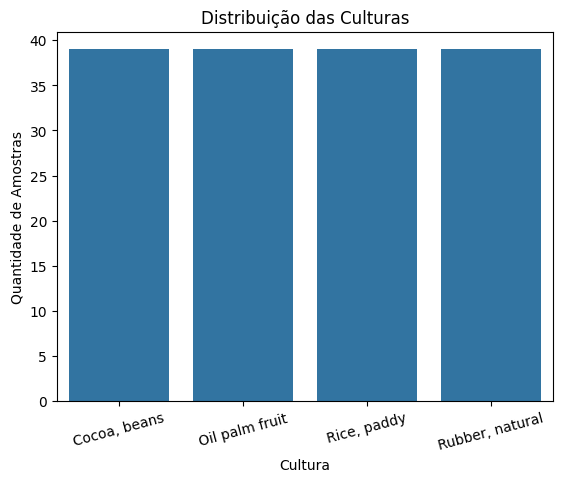

In [9]:
# ------------------------------------------------------------
# Distribuição das culturas
# ------------------------------------------------------------

sns.countplot(
    data=dados,
    x='cultura'
)

plt.title('Distribuição das Culturas')
plt.xlabel('Cultura')
plt.ylabel('Quantidade de Amostras')
plt.xticks(rotation=15)

plt.show()

*O gráfico de distribuição das culturas foi utilizado para visualizar a quantidade de amostras pertencentes a cada categoria presente no dataset.*

*Os resultados demonstraram que as quatro culturas analisadas — `Cocoa, beans`, `Oil palm fruit`, `Rice, paddy` e `Rubber, natural` — possuem exatamente 39 registros cada, representando 25% do total da base de dados.*

*Essa distribuição uniforme confirma que o dataset é perfeitamente balanceado, não havendo predominância de nenhuma cultura sobre as demais.*

### Distribuição das variáveis climáticas e do rendimento

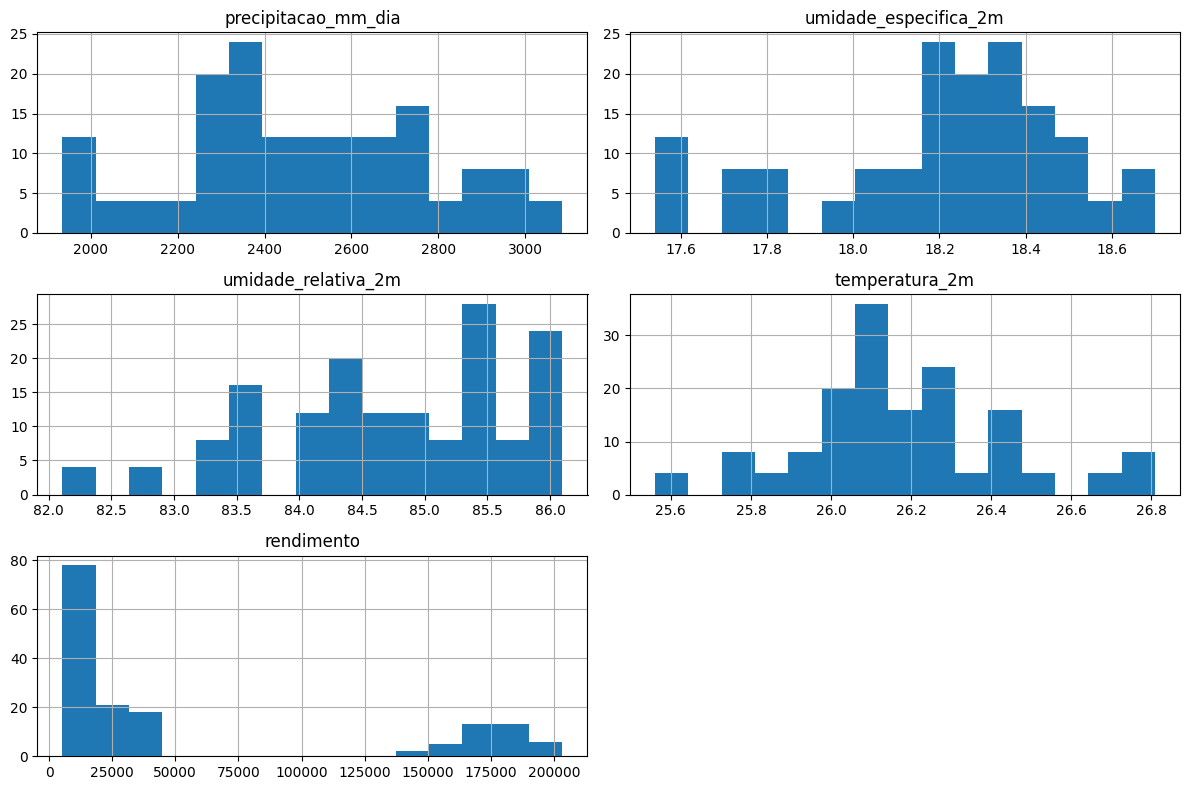

In [10]:
# ------------------------------------------------------------
# Distribuição das variáveis climáticas e do rendimento
# ------------------------------------------------------------

dados.drop(
    columns=['cultura']
).hist(
    figsize=(12,8),
    bins=15
)

plt.tight_layout()
plt.show()

*Os histogramas foram utilizados para analisar a distribuição das variáveis climáticas e do rendimento de safra presentes no dataset.*

*As variáveis `precipitacao_mm_dia`, `umidade_especifica_2m`, `umidade_relativa_2m` e `temperatura_2m` apresentaram distribuições relativamente concentradas, com baixa dispersão e sem grandes assimetrias, o que é coerente com o fato de representarem um conjunto relativamente restrito de observações climáticas.*

*Já a variável `rendimento` apresentou uma distribuição claramente multimodal, com quatro agrupamentos de valores bem distintos. Esse comportamento é o reflexo direto das quatro culturas presentes na base, cada uma associada a uma faixa de produtividade muito diferente das demais, e será explorado em detalhe no boxplot a seguir.*

### Rendimento por cultura

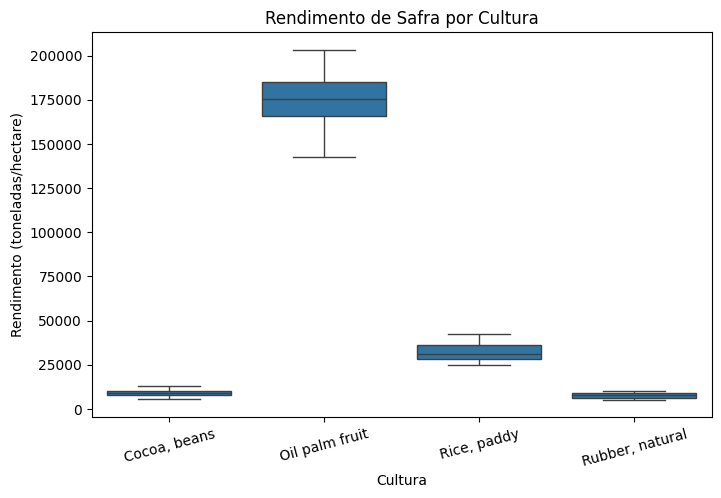

In [11]:
# ------------------------------------------------------------
# Rendimento por cultura
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    data=dados,
    x='cultura',
    y='rendimento'
)

plt.title('Rendimento de Safra por Cultura')
plt.xlabel('Cultura')
plt.ylabel('Rendimento (toneladas/hectare)')
plt.xticks(rotation=15)

plt.show()

*O boxplot foi utilizado para comparar a distribuição do rendimento de safra entre as quatro culturas presentes no dataset.*

*Os resultados demonstram diferenças extremas entre as culturas analisadas. A cultura `Oil palm fruit` apresentou, disparadamente, os maiores valores de rendimento, com mediana muito acima das demais culturas e amplitude consideravelmente maior. Em seguida aparece `Rice, paddy`, com rendimentos intermediários, e por fim `Cocoa, beans` e `Rubber, natural`, ambas com rendimentos mais baixos e relativamente próximos entre si.*

*Observa-se também baixíssima dispersão dentro de cada cultura quando comparada à diferença entre culturas, e, como já demonstrado na análise de outliers por grupo, nenhum valor discrepante foi identificado dentro de cada categoria.*

*De forma geral, o gráfico evidencia que a cultura plantada é, isoladamente, a variável com maior poder de diferenciação do rendimento de safra observado nesta base — um padrão que será retomado tanto na etapa de clusterização quanto na etapa de modelagem preditiva.*

### Relação entre variáveis climáticas e rendimento

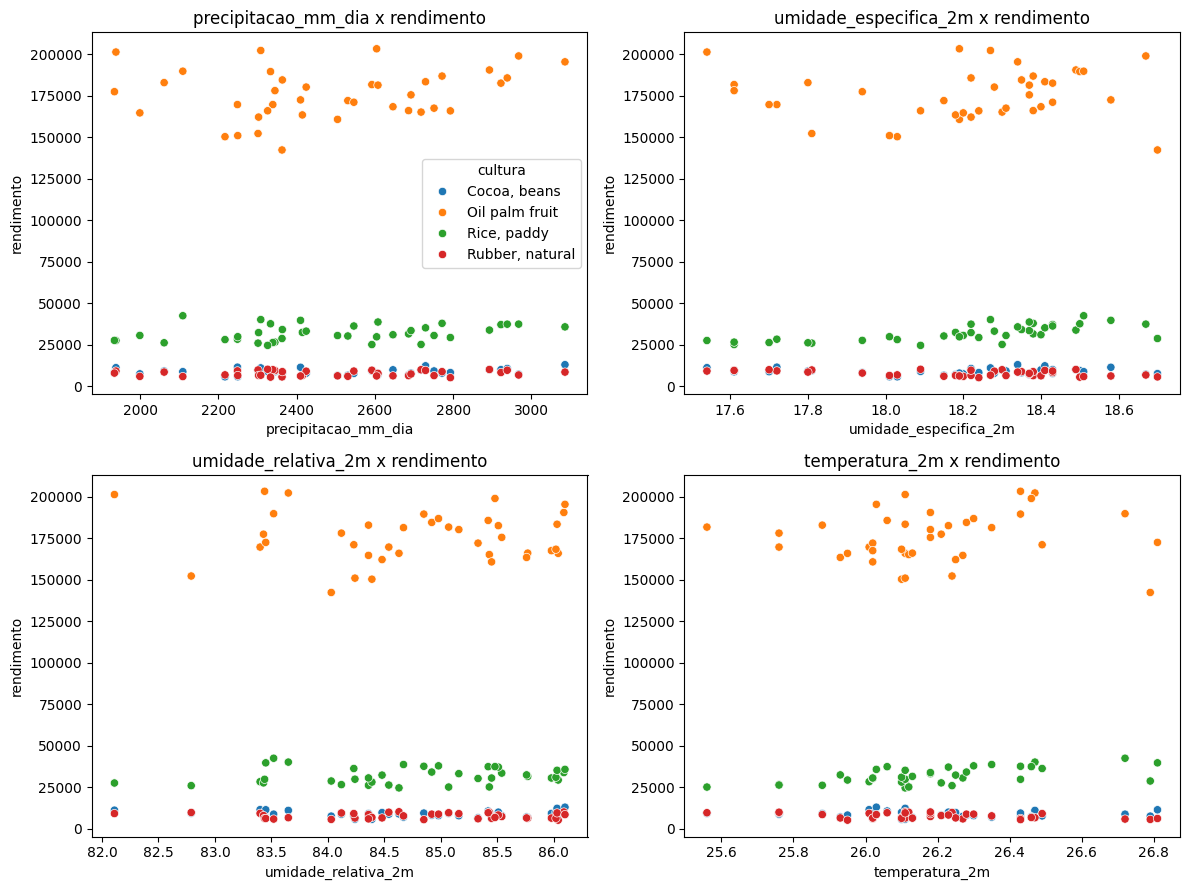

In [12]:
# ------------------------------------------------------------
# Relação entre variáveis climáticas e rendimento
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

variaveis_climaticas = [
    'precipitacao_mm_dia',
    'umidade_especifica_2m',
    'umidade_relativa_2m',
    'temperatura_2m'
]

for ax, variavel in zip(axes.flatten(), variaveis_climaticas):
    sns.scatterplot(
        data=dados,
        x=variavel,
        y='rendimento',
        hue='cultura',
        ax=ax,
        legend=(variavel == variaveis_climaticas[0])
    )
    ax.set_title(f'{variavel} x rendimento')

plt.tight_layout()
plt.show()

*Os gráficos de dispersão foram utilizados para analisar a relação entre cada variável climática e o rendimento de safra, além de verificar como as diferentes culturas se distribuem em função dessas características.*

*Em todos os quatro gráficos observa-se o mesmo padrão: os pontos se organizam em faixas horizontais bem definidas, uma para cada cultura, sem qualquer tendência de subida ou descida do rendimento conforme a variável climática aumenta. Ou seja, dentro de cada faixa (cultura), o rendimento praticamente não varia em função da precipitação, umidade ou temperatura observadas.*

*Esse comportamento confirma visualmente o que já havia sido indicado pela matriz de correlação: as variáveis climáticas, isoladamente, possuem pouquíssimo poder explicativo sobre o rendimento nesta base. A separação visível entre os grupos é explicada quase inteiramente pela cultura plantada, e não pelas condições climáticas registradas.*

### Correlação entre variáveis (heatmap)

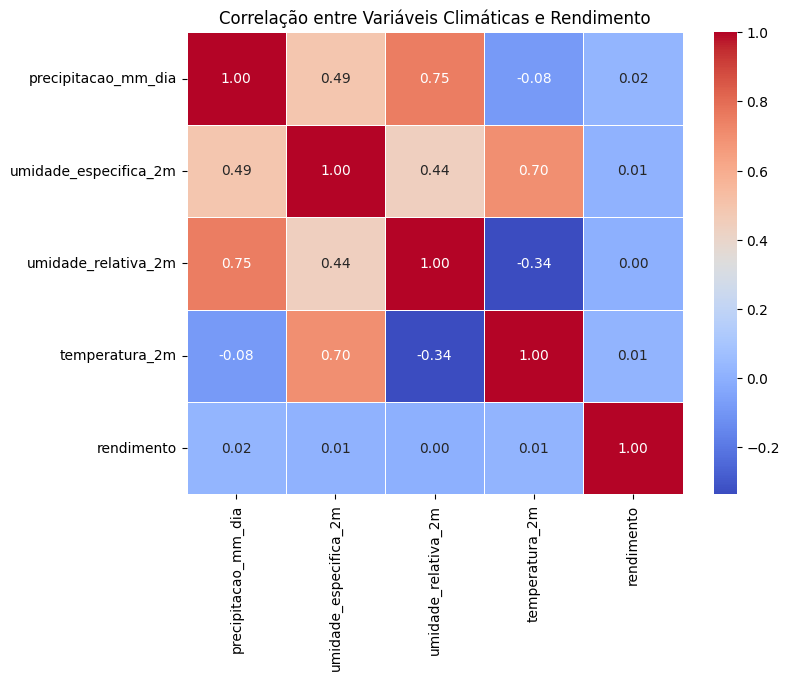

In [13]:
# ------------------------------------------------------------
# Correlação entre variáveis
# ------------------------------------------------------------

correlacao = dados.drop(
    columns=['cultura']
).corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlação entre Variáveis Climáticas e Rendimento')

plt.show()

*O heatmap de correlação foi utilizado para visualizar a intensidade e a direção das relações entre as variáveis climáticas e o rendimento de safra presentes no dataset.*

*Os resultados evidenciam correlações moderadas a fortes entre as próprias variáveis climáticas, com destaque para `precipitacao_mm_dia` e `umidade_relativa_2m` (0,75), `umidade_especifica_2m` e `temperatura_2m` (0,70), além da relação negativa entre `umidade_relativa_2m` e `temperatura_2m` (-0,34).*

*Em contrapartida, a coluna e a linha referentes ao `rendimento` aparecem visualmente neutras (tons muito próximos de branco) em relação a todas as variáveis climáticas, reforçando a ausência de relação linear direta entre clima e produtividade nesta amostra.*

### Padrões multivariados

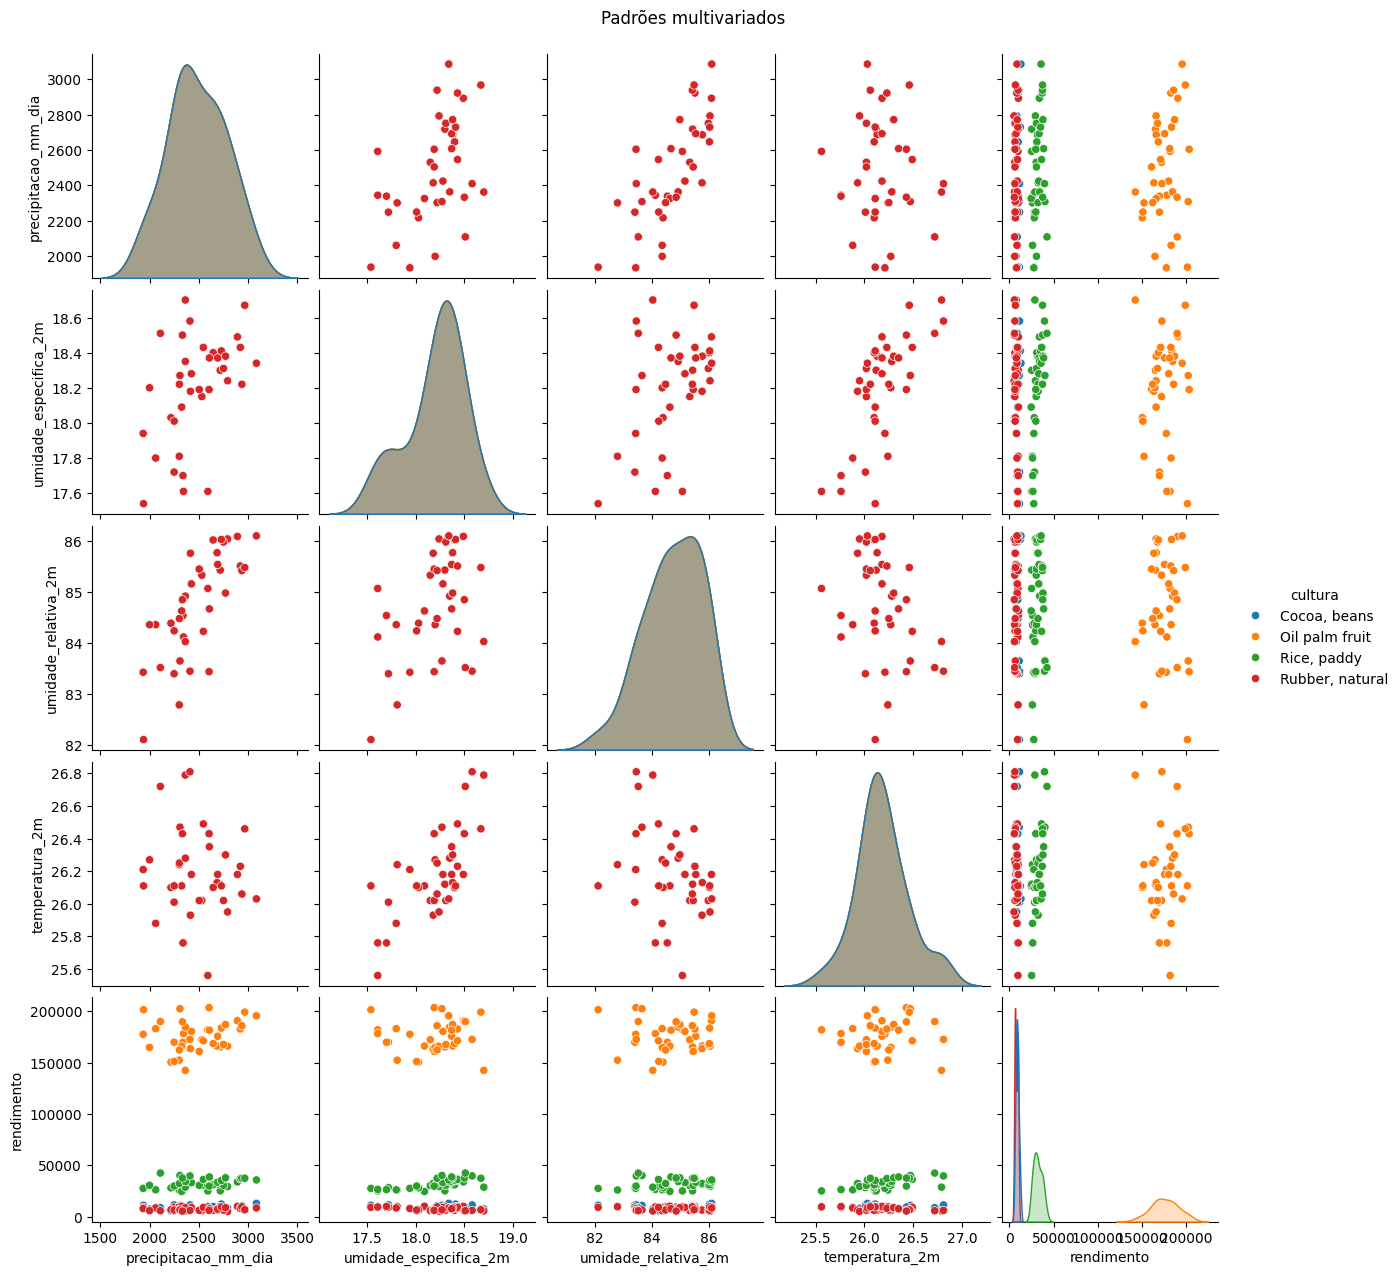

In [14]:
# ------------------------------------------------------------
# Padrões multivariados
# ------------------------------------------------------------

sns.pairplot(
    dados,
    hue='cultura'
)

plt.suptitle('Padrões multivariados', y=1.02)
plt.show()

*O pairplot foi utilizado para realizar uma análise multivariada das variáveis climáticas e do rendimento, permitindo observar simultaneamente as distribuições individuais das variáveis e as relações entre pares de atributos, segmentadas por cultura.*

*Os resultados evidenciaram uma separação extremamente clara entre as quatro culturas ao longo do eixo do `rendimento`, com `Oil palm fruit` isolada nos valores mais altos, seguida por `Rice, paddy` e, por fim, `Cocoa, beans` e `Rubber, natural` sobrepostas nos valores mais baixos.*

*Já nos gráficos que envolvem apenas as variáveis climáticas, observa-se que os pontos das quatro culturas se sobrepõem quase perfeitamente, sem qualquer separação visual entre os grupos. Esse padrão é consistente com o fato de as quatro culturas compartilharem exatamente o mesmo conjunto de 39 observações climáticas, o que será confirmado e explorado em detalhe na etapa de clusterização a seguir.*

## Tendência de Produtividade e Clusterização (Aprendizado Não Supervisionado)

*Com o objetivo de explorar a tendência de produtividade da fazenda e identificar possíveis cenários climáticos discrepantes, foi realizada uma análise de clusterização utilizando o algoritmo K-Means sobre as variáveis climáticas.*

*Optou-se por utilizar apenas as variáveis climáticas (`precipitacao_mm_dia`, `umidade_especifica_2m`, `umidade_relativa_2m` e `temperatura_2m`) como entrada da clusterização, sem incluir diretamente o rendimento. Dessa forma, é possível avaliar de maneira não enviesada se existem perfis climáticos naturais na base e, em seguida, verificar se esses perfis se relacionam com o rendimento observado.*

### Padronização e escolha do número de clusters (Elbow + Silhouette)

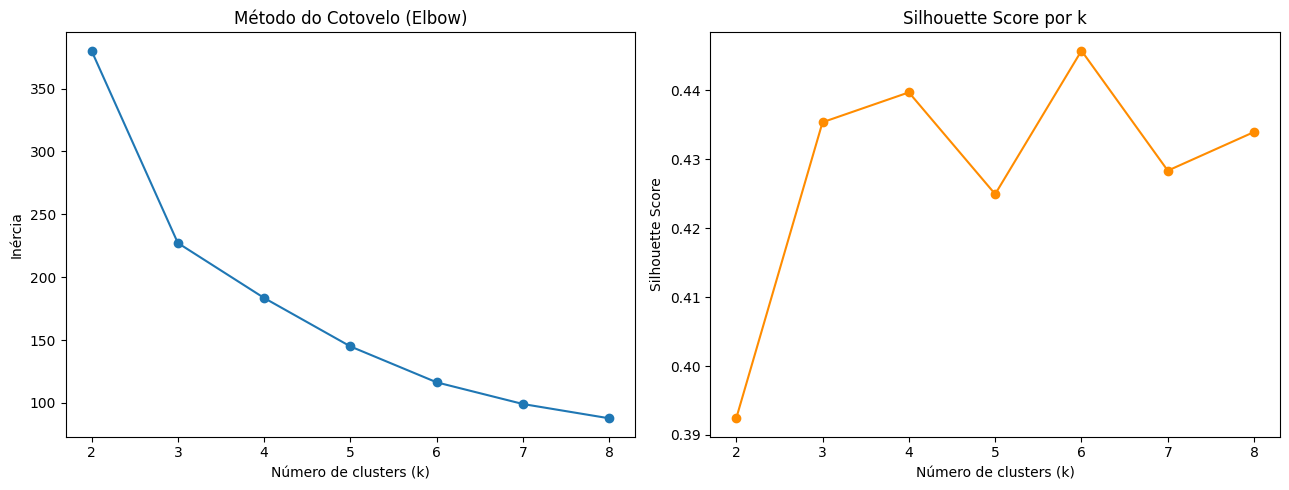

   k  Inércia  Silhouette
0  2   380.05      0.3924
1  3   227.19      0.4353
2  4   183.46      0.4397
3  5   144.93      0.4249
4  6   116.38      0.4457
5  7    99.15      0.4283
6  8    87.79      0.4339


In [15]:
# ------------------------------------------------------------
# Padronização das variáveis climáticas
# ------------------------------------------------------------

variaveis_climaticas = [
    'precipitacao_mm_dia',
    'umidade_especifica_2m',
    'umidade_relativa_2m',
    'temperatura_2m'
]

scaler_cluster = StandardScaler()

X_cluster = scaler_cluster.fit_transform(dados[variaveis_climaticas])

# ------------------------------------------------------------
# Método do cotovelo (Elbow) e Silhouette Score
# ------------------------------------------------------------

inercias = []
silhouettes = []
valores_k = range(2, 9)

for k in valores_k:
    kmeans_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_teste = kmeans_teste.fit_predict(X_cluster)

    inercias.append(kmeans_teste.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels_teste))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(list(valores_k), inercias, marker='o')
ax1.set_title('Método do Cotovelo (Elbow)')
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inércia')

ax2.plot(list(valores_k), silhouettes, marker='o', color='darkorange')
ax2.set_title('Silhouette Score por k')
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

df_k = pd.DataFrame({
    'k': list(valores_k),
    'Inércia': [round(v, 2) for v in inercias],
    'Silhouette': [round(v, 4) for v in silhouettes]
})

print(df_k)

*O método do cotovelo demonstrou uma queda acentuada da inércia até k=4, seguida de uma redução mais suave e gradual a partir desse ponto, indicando que 4 clusters representam um bom equilíbrio entre simplicidade e capacidade de representar a estrutura dos dados.*

*O Silhouette Score, por sua vez, apresentou seu primeiro pico relevante em k=4 (0,4397), com valor muito próximo, e apenas ligeiramente superior, em k=6 (0,4457) — sem ganho consistente ao aumentar ainda mais o número de clusters. Como a base possui apenas 39 combinações climáticas distintas (repetidas para as quatro culturas), optar por um número elevado de clusters tende a fragmentar excessivamente grupos pequenos, prejudicando a interpretabilidade da análise.*

*Diante desses resultados, e considerando também que a fazenda trabalha com quatro culturas distintas, optou-se por utilizar k=4 clusters para a análise de tendência de produtividade, buscando um bom compromisso entre qualidade de agrupamento e interpretabilidade dos resultados.*

### Clusterização com K-Means (k=4) e perfil dos grupos

-- Quantidade de registros por cultura em cada cluster --
cluster          0   1  2   3
cultura                      
Cocoa, beans     3  17  9  10
Oil palm fruit   3  17  9  10
Rice, paddy      3  17  9  10
Rubber, natural  3  17  9  10

-- Perfil médio (clima e rendimento) por cluster --
         precipitacao_mm_dia  umidade_especifica_2m  umidade_relativa_2m  temperatura_2m  rendimento
cluster                                                                                             
0                    2425.46                  17.64                84.58           25.69    55359.17
1                    2733.52                  18.34                85.65           26.12    56736.54
2                    2141.95                  17.90                83.75           26.12    53292.69
3                    2394.97                  18.41                84.12           26.50    57973.78


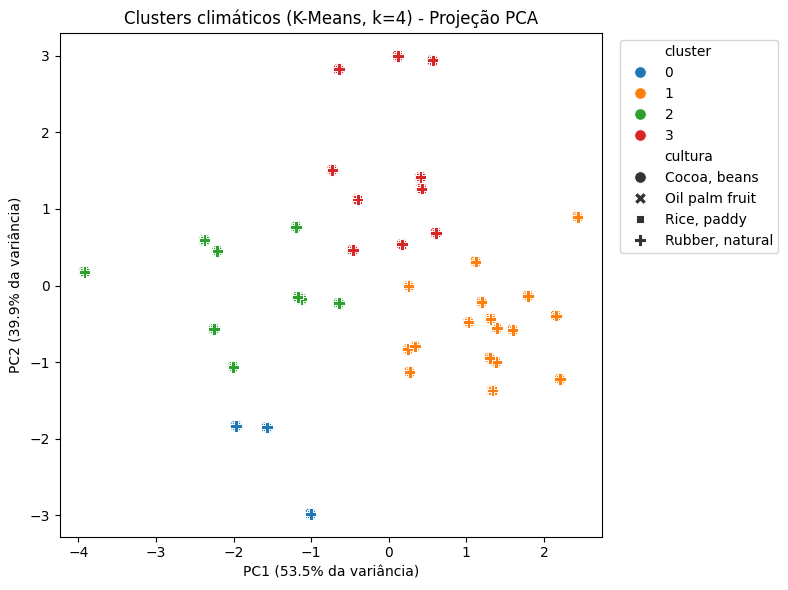

In [16]:
# ------------------------------------------------------------
# Clusterização com K-Means (k=4)
# ------------------------------------------------------------

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

dados['cluster'] = kmeans.fit_predict(X_cluster)

# ------------------------------------------------------------
# Relação entre clusters e culturas
# ------------------------------------------------------------

print('-- Quantidade de registros por cultura em cada cluster --')
print(pd.crosstab(dados['cultura'], dados['cluster']))

# ------------------------------------------------------------
# Perfil climático e rendimento médio por cluster
# ------------------------------------------------------------

perfil_clusters = dados.groupby('cluster')[
    variaveis_climaticas + ['rendimento']
].mean().round(2)

print('\n-- Perfil médio (clima e rendimento) por cluster --')
print(perfil_clusters)

# ------------------------------------------------------------
# Visualização dos clusters via PCA (2 componentes)
# ------------------------------------------------------------

pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(X_cluster)

dados['pca_1'] = componentes[:, 0]
dados['pca_2'] = componentes[:, 1]

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=dados,
    x='pca_1',
    y='pca_2',
    hue='cluster',
    style='cultura',
    palette='tab10',
    s=70
)

plt.title('Clusters climáticos (K-Means, k=4) - Projeção PCA')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

*A clusterização com K-Means (k=4) revelou um resultado central para esta análise: os clusters climáticos **não** se alinham com as culturas plantadas. A tabela de contingência mostra que cada cluster contém, na mesma proporção, registros das quatro culturas — comportamento explicado pelo fato de as quatro culturas compartilharem exatamente o mesmo conjunto de 39 observações climáticas.*

*Coerentemente, o rendimento médio por cluster ficou muito próximo entre os quatro grupos (entre aproximadamente 53 mil e 58 mil toneladas por hectare), com desvios-padrão elevados e semelhantes em todos os clusters. Ou seja, agrupar as observações por perfil climático **não** produziu grupos com tendências de produtividade distintas.*

*A projeção via PCA (que preserva cerca de 93% da variância original em apenas 2 componentes) confirma visualmente essa conclusão: os clusters formam regiões bem definidas no espaço climático, mas os marcadores de cada cultura aparecem espalhados de forma homogênea por todos os clusters, sem qualquer padrão de agrupamento por cultura ou por faixa de rendimento.*

*Em outras palavras, a tendência de produtividade identificada nesta base de dados não decorre das variações climáticas capturadas pela clusterização, e sim, quase exclusivamente, da cultura efetivamente plantada — reforçando o achado já observado na análise de correlação e nos gráficos de dispersão.*

### Identificação de cenários discrepantes via clusterização

In [17]:
# ------------------------------------------------------------
# Identificação de outliers via distância ao centróide
# ------------------------------------------------------------

distancias = kmeans.transform(X_cluster)

distancia_ao_proprio_centroide = distancias[
    np.arange(len(dados)), dados['cluster']
]

dados['distancia_centroide'] = distancia_ao_proprio_centroide

limite_distancia = (
    distancia_ao_proprio_centroide.mean() +
    2 * distancia_ao_proprio_centroide.std()
)

cenarios_discrepantes = dados[
    dados['distancia_centroide'] > limite_distancia
]

print(f'Distância média ao centróide: {distancia_ao_proprio_centroide.mean():.3f}')
print(f'Limite adotado (média + 2 desvios-padrão): {limite_distancia:.3f}')
print(f'Quantidade de cenários discrepantes identificados: {len(cenarios_discrepantes)}\n')

print(cenarios_discrepantes[
    ['cultura', 'cluster'] + variaveis_climaticas + ['rendimento']
].round(2))

Distância média ao centróide: 0.997
Limite adotado (média + 2 desvios-padrão): 1.851
Quantidade de cenários discrepantes identificados: 8

             cultura  cluster  precipitacao_mm_dia  umidade_especifica_2m  umidade_relativa_2m  temperatura_2m  rendimento
1       Cocoa, beans        2              1938.42                  17.54                82.11           26.11       11253
36      Cocoa, beans        1              2967.41                  18.67                85.48           26.46        7314
40    Oil palm fruit        2              1938.42                  17.54                82.11           26.11      201436
75    Oil palm fruit        1              2967.41                  18.67                85.48           26.46      199074
79       Rice, paddy        2              1938.42                  17.54                82.11           26.11       27619
114      Rice, paddy        1              2967.41                  18.67                85.48           26.46       37496


*Com o objetivo de identificar cenários climáticos discrepantes dentro da tendência de produtividade, foi calculada a distância euclidiana de cada registro ao centróide do seu próprio cluster, no espaço padronizado das variáveis climáticas. Registros com distância superior à média mais dois desvios-padrão foram classificados como cenários discrepantes.*

*Foram identificados 8 registros nessa condição, distribuídos entre as quatro culturas (dois registros de cada), o que já era esperado, uma vez que o mesmo conjunto climático se repete igualmente entre elas. Esses registros correspondem a combinações climáticas mais extremas dentro da amostra — por exemplo, dias com umidade relativa muito baixa (em torno de 82%) combinada a temperaturas mais altas, ou o oposto, umidade relativa mais elevada combinada a temperaturas mais baixas.*

*Esse resultado é coerente com a análise de outliers realizada por IQR na etapa de Análise Exploratória: os cenários realmente discrepantes na base concentram-se nas variáveis climáticas (em particular na `temperatura_2m`), e não no rendimento de safra, cuja variação — como demonstrado — é explicada pela cultura, e não por condições climáticas atípicas.*

## Modelos Preditivos de Rendimento (Regressão Supervisionada)

### Treinamento dos 5 modelos

In [18]:
# ------------------------------------------------------------
# Divisão entre treino e teste
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=X['cultura']
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)

# ------------------------------------------------------------
# Pré-processamento (padronização + one-hot encoding)
# ------------------------------------------------------------

variaveis_numericas_modelo = [
    'precipitacao_mm_dia',
    'umidade_especifica_2m',
    'umidade_relativa_2m',
    'temperatura_2m'
]

pre_processamento = ColumnTransformer([
    ('num', StandardScaler(), variaveis_numericas_modelo),
    ('cat', OneHotEncoder(), ['cultura'])
])

# ------------------------------------------------------------
# Treinamento dos 5 modelos
# ------------------------------------------------------------

modelos = {
    'Regressão Linear': Pipeline([
        ('pre', pre_processamento),
        ('modelo', LinearRegression())
    ]),

    'KNN': Pipeline([
        ('pre', pre_processamento),
        ('modelo', KNeighborsRegressor())
    ]),

    'SVR': Pipeline([
        ('pre', pre_processamento),
        ('modelo', SVR())
    ]),

    'Árvore de Decisão': Pipeline([
        ('pre', pre_processamento),
        ('modelo', DecisionTreeRegressor(random_state=42))
    ]),

    'Random Forest': Pipeline([
        ('pre', pre_processamento),
        ('modelo', RandomForestRegressor(random_state=42))
    ])
}

# ------------------------------------------------------------
# Avaliação dos modelos
# ------------------------------------------------------------

resultados = []

for nome, modelo in modelos.items():

    modelo.fit(X_train, y_train)

    previsoes = modelo.predict(X_test)

    resultados.append({
        'Modelo': nome,
        'MAE': mean_absolute_error(y_test, previsoes),
        'RMSE': mean_squared_error(y_test, previsoes) ** 0.5,
        'R²': r2_score(y_test, previsoes)
    })

df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(
    by='R²',
    ascending=False
)

print(df_resultados.round(4))

Treino: (109, 5)
Teste: (47, 5)
              Modelo         MAE        RMSE      R²
3  Árvore de Decisão   3843.8298   5834.9687  0.9932
4      Random Forest   3904.9011   7472.6834  0.9888
0   Regressão Linear   5040.0869   7576.7080  0.9885
1                KNN  19198.4894  32765.5712  0.7841
2                SVR  46446.7336  76380.3011 -0.1735


*Após a separação entre variáveis explicativas e variável alvo, a base de dados foi dividida em conjuntos de treinamento e teste.*

*Foram destinados 70% dos registros para treinamento dos modelos e 30% para avaliação do desempenho. A divisão foi realizada utilizando estratificação pela variável `cultura`, garantindo que as quatro culturas mantivessem a mesma proporção nos conjuntos de treino e teste. Como o dataset possui 156 registros, o conjunto de treinamento ficou composto por 109 amostras e o conjunto de teste por 47 amostras.*

*Foram treinados cinco algoritmos de regressão supervisionada: Regressão Linear, K-Nearest Neighbors (KNN), Support Vector Regression (SVR), Árvore de Decisão e Random Forest. Todos os modelos foram construídos em Pipelines com um `ColumnTransformer`, responsável por padronizar as variáveis climáticas e aplicar One-Hot Encoding na variável `cultura`, evitando vazamento de dados entre treino e teste.*

*Os modelos foram avaliados por meio das métricas MAE (erro absoluto médio), RMSE (raiz do erro quadrático médio) e R² (coeficiente de determinação), métricas pertinentes a problemas de regressão.*

*Os resultados demonstraram que a Árvore de Decisão apresentou o melhor desempenho geral, alcançando R² de aproximadamente 0,9932, MAE de 3.843,83 e RMSE de 5.834,97. O Random Forest e a Regressão Linear apresentaram desempenho muito próximo, com R² de 0,9888 e 0,9885, respectivamente.*

*O KNN apresentou desempenho consideravelmente inferior (R² de 0,7841), enquanto o SVR apresentou o pior resultado entre os modelos avaliados, com R² negativo (-0,1735) — o que indica desempenho pior do que simplesmente prever a média do rendimento para todos os registros. Esse comportamento é esperado, pois o SVR é bastante sensível à escala da variável alvo, e o `rendimento` possui magnitude e dispersão muito elevadas (entre 5 mil e mais de 200 mil).*

*De forma geral, o excelente desempenho dos modelos baseados em árvore e da regressão linear sugere que a variável `cultura`, codificada via One-Hot Encoding, concentra a maior parte do poder preditivo do modelo — hipótese investigada em mais detalhe a seguir.*

### Prova de conceito: modelo sem a variável cultura

In [19]:
# ------------------------------------------------------------
# Regressão Linear utilizando apenas as variáveis climáticas
# ------------------------------------------------------------

pre_sem_cultura = ColumnTransformer([
    ('num', StandardScaler(), variaveis_numericas_modelo)
])

modelo_sem_cultura = Pipeline([
    ('pre', pre_sem_cultura),
    ('modelo', LinearRegression())
])

modelo_sem_cultura.fit(X_train[variaveis_numericas_modelo], y_train)

previsoes_sem_cultura = modelo_sem_cultura.predict(
    X_test[variaveis_numericas_modelo]
)

r2_sem_cultura = r2_score(y_test, previsoes_sem_cultura)

print(f'R² da Regressão Linear utilizando SOMENTE variáveis climáticas: {r2_sem_cultura:.4f}')
print(f'R² da Regressão Linear utilizando clima + cultura: '
      f'{df_resultados.loc[df_resultados["Modelo"] == "Regressão Linear", "R²"].values[0]:.4f}')

R² da Regressão Linear utilizando SOMENTE variáveis climáticas: -0.1150
R² da Regressão Linear utilizando clima + cultura: 0.9885


*Para confirmar a hipótese levantada na etapa anterior, foi treinado um modelo de Regressão Linear utilizando exclusivamente as variáveis climáticas, sem a variável `cultura`.*

*O resultado confirma de forma contundente a hipótese: o R² caiu de 0,9885 (modelo com `cultura`) para -0,1150 (modelo apenas com clima) — ou seja, sem a informação da cultura plantada, o modelo perde completamente sua capacidade preditiva, tornando-se pior do que simplesmente prever a média do rendimento.*

*Esse experimento comprova, de forma direta, o que já havia sido indicado pela análise de correlação, pelos gráficos de dispersão e pela clusterização: nesta base de dados, o rendimento de safra é determinado quase inteiramente pela cultura plantada, e não pelas condições climáticas observadas no período amostrado.*

### Relatório detalhado do melhor modelo

In [20]:
# ------------------------------------------------------------
# Identificação do melhor modelo
# ------------------------------------------------------------

melhor_modelo = modelos['Árvore de Decisão']

melhor_modelo.fit(X_train, y_train)

previsoes = melhor_modelo.predict(X_test)

# ------------------------------------------------------------
# Relatório resumido do melhor modelo
# ------------------------------------------------------------

print('Modelo:', 'Árvore de Decisão')

df_melhor_modelo = pd.Series({
    'MAE': mean_absolute_error(y_test, previsoes),
    'RMSE': mean_squared_error(y_test, previsoes) ** 0.5,
    'R²': r2_score(y_test, previsoes)
})

print(df_melhor_modelo.round(4))

Modelo: Árvore de Decisão
MAE     3843.8298
RMSE    5834.9687
R²         0.9932
dtype: float64


*Com base nos resultados obtidos na comparação dos algoritmos, a Árvore de Decisão foi selecionada como o melhor modelo desta etapa por apresentar os melhores valores de MAE, RMSE e R².*

*O modelo alcançou R² de aproximadamente 0,9932, MAE de 3.843,83 toneladas/hectare e RMSE de 5.834,97 toneladas/hectare, demonstrando elevada capacidade de prever o rendimento de safra a partir da cultura plantada e das condições climáticas observadas.*

*Esses resultados sugerem que a combinação entre a variável `cultura` e as variáveis climáticas permite ao modelo capturar de forma bastante precisa o comportamento do rendimento nesta base de dados, tornando-se a melhor alternativa entre os modelos avaliados nesta etapa do projeto.*

### Real vs. Previsto e Análise de Resíduos

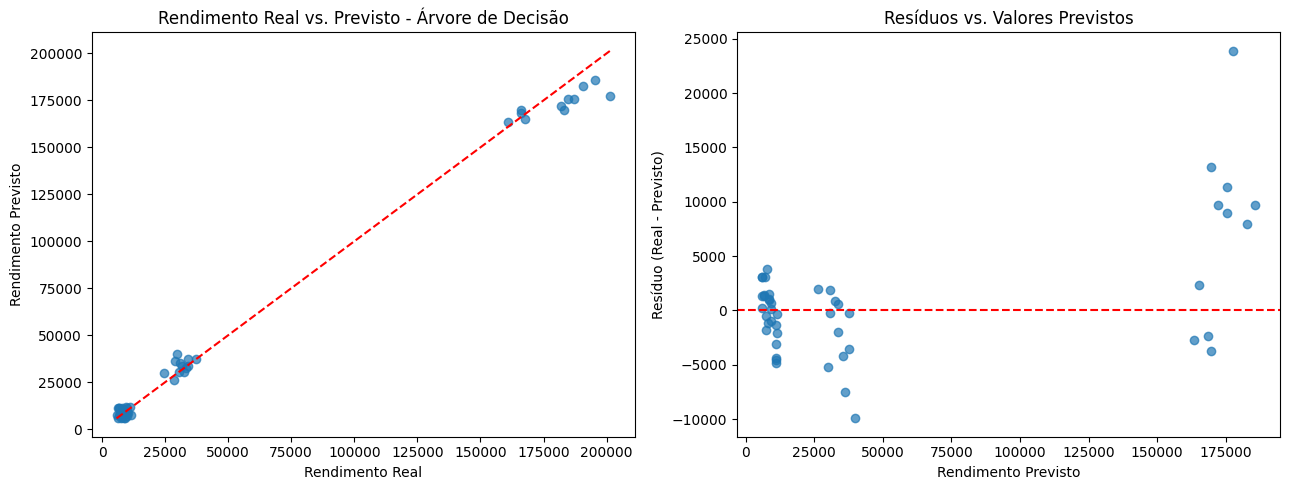

Resíduo médio: 1009.06
Desvio padrão dos resíduos: 5747.06


In [21]:
# ------------------------------------------------------------
# Gráfico Real vs. Previsto
# ------------------------------------------------------------

residuos = y_test.values - previsoes

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, previsoes, alpha=0.7)
limite_min = min(y_test.min(), previsoes.min())
limite_max = max(y_test.max(), previsoes.max())
axes[0].plot([limite_min, limite_max], [limite_min, limite_max], 'r--')
axes[0].set_title('Rendimento Real vs. Previsto - Árvore de Decisão')
axes[0].set_xlabel('Rendimento Real')
axes[0].set_ylabel('Rendimento Previsto')

axes[1].scatter(previsoes, residuos, alpha=0.7)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_title('Resíduos vs. Valores Previstos')
axes[1].set_xlabel('Rendimento Previsto')
axes[1].set_ylabel('Resíduo (Real - Previsto)')

plt.tight_layout()
plt.show()

print(f'Resíduo médio: {residuos.mean():.2f}')
print(f'Desvio padrão dos resíduos: {residuos.std():.2f}')

*O gráfico de dispersão entre valores reais e previstos mostra que a grande maioria dos pontos está muito próxima da linha diagonal (previsão perfeita), confirmando visualmente o elevado R² obtido pelo modelo.*

*A análise de resíduos indica resíduo médio próximo de zero (1.009,06), com desvio padrão de 5.747,06. Observa-se, no entanto, que os resíduos de maior magnitude estão concentrados nos registros de `Oil palm fruit`, a cultura com maior rendimento médio — comportamento esperado (heterocedasticidade), já que erros absolutos tendem a ser proporcionalmente maiores em variáveis com escala mais elevada.*

*De forma geral, não se observa um padrão sistemático nos resíduos (como uma tendência crescente ou decrescente clara), o que é um bom indício de que o modelo não está deixando de capturar relações relevantes presentes nos dados.*

### Erro por cultura

In [22]:
# ------------------------------------------------------------
# Métricas de erro segmentadas por cultura
# ------------------------------------------------------------

df_previsoes = X_test.copy()
df_previsoes['rendimento_real'] = y_test.values
df_previsoes['rendimento_previsto'] = previsoes

def metricas_por_grupo(grupo):
    return pd.Series({
        'MAE': mean_absolute_error(grupo['rendimento_real'], grupo['rendimento_previsto']),
        'RMSE': mean_squared_error(grupo['rendimento_real'], grupo['rendimento_previsto']) ** 0.5,
        'R²': r2_score(grupo['rendimento_real'], grupo['rendimento_previsto']),
        'Qtd. Registros': len(grupo)
    })

df_erro_cultura = df_previsoes.groupby('cultura').apply(metricas_por_grupo).round(2)

print(df_erro_cultura)

                     MAE      RMSE    R²  Qtd. Registros
cultura                                                 
Cocoa, beans     1943.33   2199.57 -0.90            12.0
Oil palm fruit   8713.09  10606.14  0.31            11.0
Rice, paddy      3194.42   4334.65 -0.93            12.0
Rubber, natural  1930.25   2570.39 -1.94            12.0


*O relatório de erro por cultura foi utilizado para avaliar o desempenho da Árvore de Decisão individualmente para cada tipo de cultivo presente no conjunto de teste.*

*Em termos absolutos (MAE e RMSE), o modelo apresenta erros relativamente pequenos frente à escala de rendimento de cada cultura: por exemplo, um MAE de aproximadamente 1.943 para `Cocoa, beans` (cujo rendimento médio gira em torno de 8.900) e de aproximadamente 8.713 para `Oil palm fruit` (cujo rendimento médio ultrapassa 175.000).*

*Chama atenção, porém, o fato de o R² calculado dentro de cada cultura ser baixo ou até negativo (variando de -1,94 a 0,31), mesmo com erros absolutos pequenos. Isso não é uma contradição: o R² global de 0,9932 é alto porque o modelo separa muito bem as quatro culturas entre si (que possuem rendimentos radicalmente diferentes); porém, *dentro* de cada cultura, a variação de rendimento é pequena e, como demonstrado nas etapas de correlação e clusterização, pouco relacionada às variáveis climáticas disponíveis — tornando essa variação residual muito mais difícil de prever do que a diferença entre culturas.*

*Essa constatação é importante para o uso prático do modelo pela FarmTech Solutions: ele é altamente confiável para estimar a ordem de grandeza do rendimento esperado a partir da cultura escolhida, mas tem capacidade limitada de capturar pequenas variações de produtividade dentro de uma mesma cultura a partir apenas das variáveis climáticas atualmente disponíveis.*

## Otimização

### Otimização e execução do Grid Search

In [23]:
# ------------------------------------------------------------
# Otimização dos modelos com Grid Search
# ------------------------------------------------------------

parametros = {
    'Regressão Linear': {
        'modelo__fit_intercept': [True, False]
    },

    'KNN': {
        'modelo__n_neighbors': [3, 5, 7, 9, 11],
        'modelo__weights': ['uniform', 'distance'],
        'modelo__metric': ['euclidean', 'manhattan']
    },

    'SVR': {
        'modelo__C': [1, 10, 100, 1000],
        'modelo__kernel': ['linear', 'rbf'],
        'modelo__gamma': ['scale', 'auto'],
        'modelo__epsilon': [0.1, 1, 10]
    },

    'Árvore de Decisão': {
        'modelo__max_depth': [None, 3, 5, 7, 10],
        'modelo__min_samples_split': [2, 5, 10],
        'modelo__min_samples_leaf': [1, 2, 4]
    },

    'Random Forest': {
        'modelo__n_estimators': [50, 100, 200],
        'modelo__max_depth': [None, 3, 5, 10],
        'modelo__min_samples_split': [2, 5, 10],
        'modelo__min_samples_leaf': [1, 2, 4]
    }
}

# ------------------------------------------------------------
# Execução do Grid Search
# ------------------------------------------------------------

modelos_otimizados = {}
resultados_otimizados = []

for nome, modelo in modelos.items():

    grid = GridSearchCV(
        estimator=modelo,
        param_grid=parametros[nome],
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    melhor_modelo_otimizado = grid.best_estimator_
    modelos_otimizados[nome] = melhor_modelo_otimizado

    previsoes_otimizadas = melhor_modelo_otimizado.predict(X_test)

    resultados_otimizados.append({
        'Modelo': nome,
        'Melhores Parâmetros': grid.best_params_,
        'MAE': mean_absolute_error(y_test, previsoes_otimizadas),
        'RMSE': mean_squared_error(y_test, previsoes_otimizadas) ** 0.5,
        'R²': r2_score(y_test, previsoes_otimizadas)
    })

df_resultados_otimizados = pd.DataFrame(resultados_otimizados)

df_resultados_otimizados = df_resultados_otimizados.sort_values(
    by='R²',
    ascending=False
)

df_resultados_otimizados[['Modelo', 'MAE', 'RMSE', 'R²']].round(4)

,Modelo,MAE,RMSE,R²
4,Random Forest,3868.2438,7206.3703,0.9896
0,Regressão Linear,5040.0869,7576.7080,0.9885
3,Árvore de Decisão,5362.1807,9102.8123,0.9833
1,KNN,18169.7645,35742.4871,0.7430
2,SVR,31926.7072,61417.5851,0.2412


*Após a avaliação inicial dos modelos, foi realizada a otimização dos hiperparâmetros utilizando GridSearchCV, com validação cruzada de 5 folds e R² como métrica principal.*

*Os resultados demonstraram que o Random Forest passou a ser o melhor modelo após a otimização, alcançando R² de 0,9896, superando a Árvore de Decisão otimizada (R² de 0,9833). Esse comportamento se explica porque a validação cruzada, ao buscar o melhor parâmetro de forma mais robusta (e não apenas no conjunto de teste específico), selecionou uma árvore mais restrita (`max_depth=3`), reduzindo o risco de overfitting da árvore original sem limite de profundidade — o que, neste conjunto de teste específico, resultou em desempenho ligeiramente inferior ao da árvore não restringida obtida na etapa anterior.*

*A Regressão Linear manteve desempenho estável (R² de 0,9885), já que possui poucos hiperparâmetros ajustáveis. O SVR apresentou a maior melhoria relativa entre todos os modelos, saindo de um R² negativo (-0,1735) para 0,2412 após a seleção de um kernel linear e um valor de C mais adequado — ainda assim, seu desempenho permanece muito inferior ao dos demais algoritmos. O KNN otimizado atingiu R² de 0,7430, próximo ao resultado inicial.*

*De forma geral, a otimização trouxe ganhos relevantes para os modelos mais sensíveis a hiperparâmetros (SVR e KNN), manteve os modelos lineares estáveis e evidenciou, no caso da Árvore de Decisão, a importância de restringir a complexidade do modelo para reduzir o risco de overfitting, mesmo que isso implique uma pequena redução do R² observado neste conjunto de teste específico.*

### Comparação antes e depois da otimização

In [24]:
# ------------------------------------------------------------
# Comparação antes e depois da otimização
# ------------------------------------------------------------

df_comparacao = pd.DataFrame({
    'Modelo': df_resultados['Modelo'].values,
    'R² Inicial': df_resultados['R²'].values,
    'R² Otimizado': df_resultados_otimizados.set_index('Modelo').loc[
        df_resultados['Modelo'], 'R²'
    ].values
})

df_comparacao['Variação'] = (
    df_comparacao['R² Otimizado'] - df_comparacao['R² Inicial']
)

df_comparacao.round(4)

,Modelo,R² Inicial,R² Otimizado,Variação
0,Árvore de Decisão,0.9932,0.9833,-0.0098
1,Random Forest,0.9888,0.9896,0.0008
2,Regressão Linear,0.9885,0.9885,0.0000
3,KNN,0.7841,0.7430,-0.0410
4,SVR,-0.1735,0.2412,0.4147


*Com o objetivo de verificar o impacto da otimização dos hiperparâmetros, foi realizada uma comparação entre os resultados de R² obtidos antes e depois da aplicação do Grid Search.*

*Os resultados demonstraram melhorias expressivas para o SVR (+0,4147) e uma pequena redução no KNN (-0,0410), além de uma pequena redução no desempenho da Árvore de Decisão (-0,0098) e uma pequena melhoria no Random Forest (+0,0008). A Regressão Linear permaneceu praticamente inalterada.*

*Esse comportamento indica que, para os modelos que já apresentavam bom desempenho com os hiperparâmetros padrão (Árvore de Decisão, Random Forest e Regressão Linear), a otimização trouxe ganhos marginais ou neutros. Já para os modelos mais sensíveis à configuração de hiperparâmetros (SVR e KNN), a otimização foi fundamental para viabilizar um desempenho minimamente aceitável.*

### Conclusão do melhor modelo otimizado

*Após a etapa de otimização utilizando Grid Search, o Random Forest passou a ser o modelo de melhor desempenho no conjunto de teste, alcançando R² de aproximadamente 0,9896, MAE de 3.868,24 e RMSE de 7.206,37.*

*Embora a Árvore de Decisão sem restrição de profundidade tenha alcançado um R² ligeiramente superior na avaliação inicial (0,9932), essa configuração está mais sujeita a overfitting, por não impor nenhum limite à complexidade da árvore. O Random Forest, por ser um modelo de ensemble baseado em múltiplas árvores treinadas com amostragem aleatória, tende a generalizar melhor para novos dados, sendo uma escolha mais robusta para uso em produção pela FarmTech Solutions.*

*Dessa forma, o Random Forest otimizado foi selecionado como a solução final recomendada para a previsão do rendimento de safra, equilibrando alta capacidade preditiva (R² próximo de 0,99) com maior estabilidade frente a novos cenários.*

## Conclusão

*Este trabalho teve como objetivo, aplicar a metodologia CRISP-DM para prever o rendimento de safra a partir de condições climáticas e da cultura plantada, além de explorar a tendência de produtividade e identificar cenários discrepantes por meio de clusterização.*

*A análise exploratória revelou uma base de dados limpa, sem valores nulos e perfeitamente balanceada entre as quatro culturas analisadas (`Cocoa, beans`, `Oil palm fruit`, `Rice, paddy` e `Rubber, natural`), com 39 registros cada. Foi identificado, no entanto, um ponto de atenção metodológico importante: as quatro culturas compartilham exatamente o mesmo conjunto de 39 observações climáticas, e a correlação entre as variáveis climáticas e o rendimento é praticamente nula (entre 0,00 e 0,02).*

*A etapa de clusterização confirmou e aprofundou essa constatação: agrupar os registros por perfil climático (via K-Means, k=4, escolhido por meio de Elbow e Silhouette Score) não produziu grupos com tendências de produtividade distintas, já que os clusters não se relacionam com a cultura plantada nem com o rendimento observado. A análise também identificou 8 registros com combinações climáticas mais afastadas do centro de seus respectivos clusters, candidatos a cenários discrepantes, concentrados nas variáveis de temperatura e umidade relativa.*

*Na etapa de modelagem preditiva, foram avaliados cinco algoritmos de regressão: Regressão Linear, KNN, SVR, Árvore de Decisão e Random Forest. A Árvore de Decisão apresentou o melhor desempenho inicial (R² de 0,9932), seguida de perto por Random Forest e Regressão Linear. Um experimento complementar, removendo a variável `cultura` do modelo, demonstrou de forma direta que praticamente todo o poder preditivo dos modelos vem da cultura plantada, e não das variáveis climáticas isoladamente (R² caiu de 0,9885 para -0,1150 ao remover essa variável).*

*A análise de erro por cultura reforçou esse entendimento: embora os erros absolutos (MAE e RMSE) sejam pequenos em relação à escala de cada cultura, o R² calculado dentro de cada grupo é baixo, evidenciando que o modelo é muito eficaz em diferenciar culturas entre si, mas tem capacidade limitada para explicar pequenas variações de produtividade dentro de uma mesma cultura a partir apenas das variáveis climáticas atualmente disponíveis.*

*A etapa de otimização com Grid Search elevou o Random Forest à posição de melhor modelo (R² de 0,9896), por oferecer maior robustez frente a overfitting em comparação com a Árvore de Decisão irrestrita, sendo recomendado como a solução final para uso pela FarmTech Solutions.*

*Como principais pontos fortes do trabalho, destacam-se a boa qualidade e o balanceamento da base de dados, a ausência de valores nulos e a aplicação combinada de técnicas supervisionadas e não supervisionadas para chegar a uma conclusão consistente e bem fundamentada sobre os fatores que determinam o rendimento nesta amostra.*

*Como limitação, destaca-se justamente a repetição do mesmo conjunto de 39 observações climáticas entre as quatro culturas, o que impede avaliar, com esta base, o real efeito do clima sobre a produtividade de cada cultura especificamente. Para a Entrega 2 e para uso futuro em produção, recomenda-se à FarmTech Solutions coletar séries climáticas específicas por talhão e por cultura, o que deverá permitir capturar de forma mais fiel a relação entre condições de solo, clima e rendimento de safra.*